In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning
        ↓
Exploratory Data Analysis (EDA)
        ↓
Feature Engineering
        ↓
Encoding
        ↓
Define X and y
        ↓
Train-Test Split
        ↓
Feature Scaling (if required)
        ↓
(Optional) PCA / Feature Selection
        ↓
Train Multiple Models
        ↓
Cross Validation
        ↓
Hyperparameter Tuning
        ↓
Final Model Selection
        ↓
Evaluation on Test Set
        ↓
Save Model
        ↓
Deployment (Streamlit)
        ↓
GitHub + README

In [3]:
data = pd.read_csv(r"C:\Users\shobh\OneDrive\Attachments\Documents\Desktop\py\Mall_Customers.csv")

df = pd.DataFrame(data)

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# project description

Customer Segmentation & Marketing Strategy using Machine Learning is an unsupervised machine learning project that uses the K-Means Clustering algorithm to group customers based on purchasing behavior. The project enables businesses to identify distinct customer segments, personalize marketing campaigns, optimize customer engagement, and improve strategic decision-making through data-driven insights.

In [6]:
#dataset understanding 

# outliers detection 

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)


outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]

outliers

-1.625 79.375


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


<h2 style="color:#059669;">➤ Observation :</h2></b> <b>➜ This Dataset have no outliers

In [7]:
#data cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [17]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [18]:
df.nunique()

CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

In [19]:
df.value_counts()

CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
1           Male    19   15                  39                        1
2           Male    21   15                  81                        1
3           Female  20   16                  6                         1
4           Female  23   16                  77                        1
5           Female  31   17                  40                        1
                                                                      ..
196         Female  35   120                 79                        1
197         Female  45   126                 28                        1
198         Male    32   126                 74                        1
199         Male    32   137                 18                        1
200         Male    30   137                 83                        1
Name: count, Length: 200, dtype: int64

In [23]:
df.sample(30)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
43,44,Female,31,39,61
45,46,Female,24,39,65
181,182,Female,32,97,86
188,189,Female,41,103,17
16,17,Female,35,21,35
55,56,Male,47,43,41
152,153,Female,44,78,20
47,48,Female,27,40,47
153,154,Female,38,78,76
163,164,Female,31,81,93


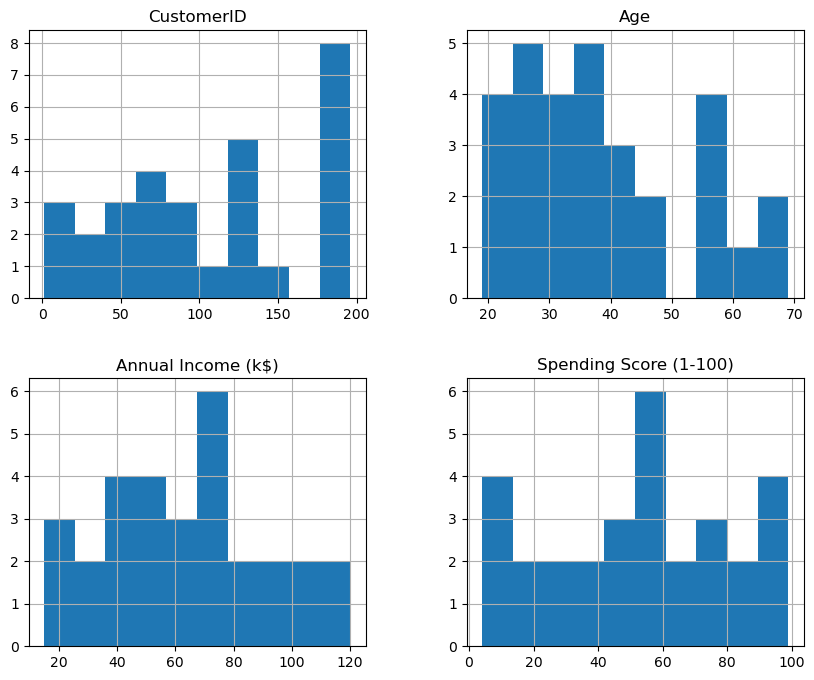

In [32]:
import matplotlib.pyplot as plt

app.hist(figsize=(10, 8))
plt.show()

<h2 style="color:#B91C1C; font-family:Georgia;">
Graphs for Data Visualization :
</h2>

In [33]:
df.sample()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
199,200,Male,30,137,83


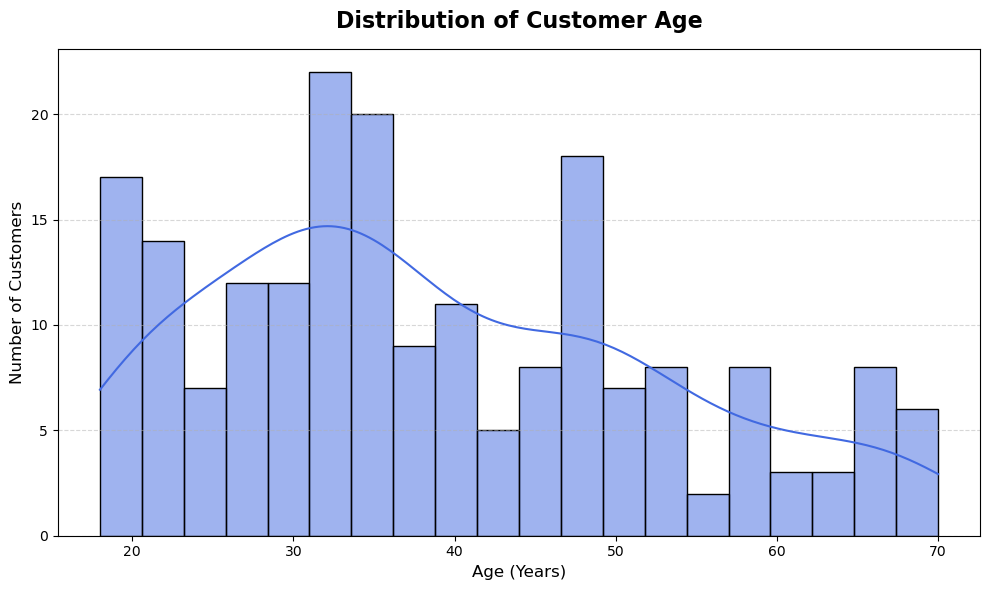

In [41]:
#Age distribution

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='Age',  bins=20, color='royalblue', edgecolor='black' ,kde=True)

plt.title("Distribution of Customer Age", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()


plt.savefig(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\Graphs\Age Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

In [42]:
df.sample()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
160,161,Female,56,79,35


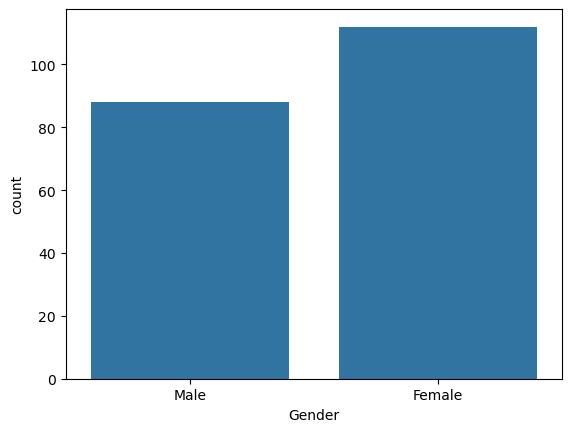

In [47]:
# Count of Customers by Gender

sns.countplot(x = df['Gender'])

plt.show()